In [11]:
import numpy as np
import matplotlib.pyplot as plt
##!pip install muldoon 

from scipy.stats import mode

from muldoon.met_timeseries import PressureTimeseries
from muldoon.utils import *
from muldoon.read_data import *

Processing file: https://pds-atmospheres.nmsu.edu/PDS/data/PDS4/Mars2020/mars2020_meda/data_derived_env/sol_0090_0179/sol_0104/WE__0104___________DER_PS__________________P01.CSV


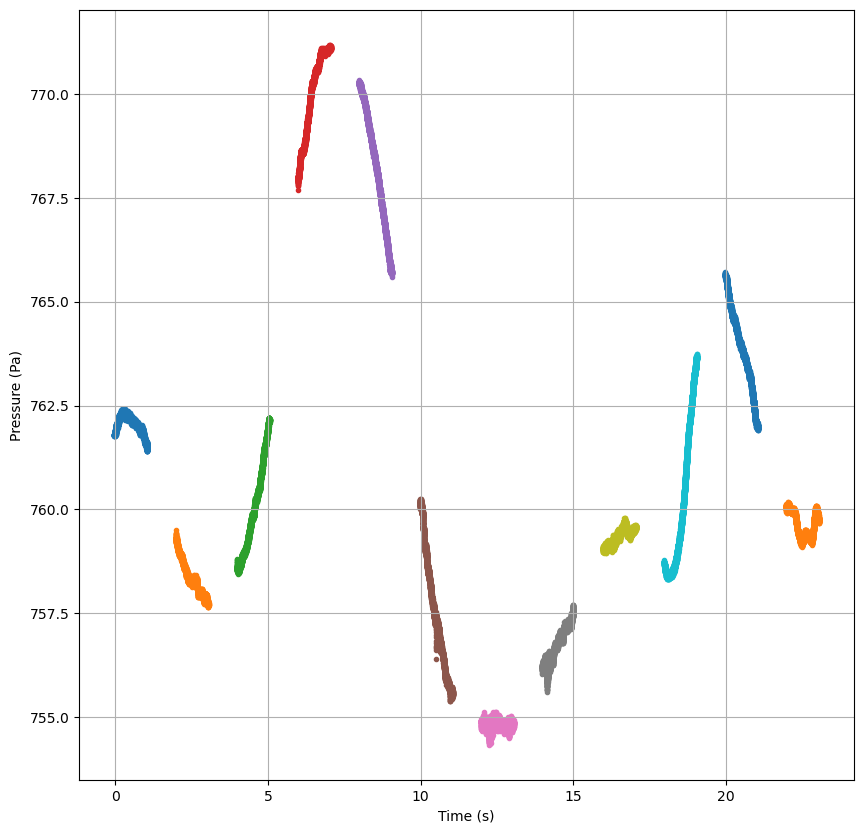

In [76]:
## File name must be changed to the correct file path per sol
filename = (
    "https://pds-atmospheres.nmsu.edu/PDS/data/PDS4/Mars2020/"
    "mars2020_meda/data_derived_env/"
    "sol_0090_0179/sol_0104/"
    "WE__0104___________DER_PS__________________P01.CSV"
)
time, pressure = read_Perseverance_PS_data(filename)
# plt.scatter(time, pressure)

times, pressures = break_at_gaps(time, pressure)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

for i in range(len(times)):
#     plt.axvline(time[0:-1][gaps][i])
    ax.scatter(times[i], pressures[i], marker='.')
ax.grid(True)

Text(0, 0.5, 'Pressure (Pa)')

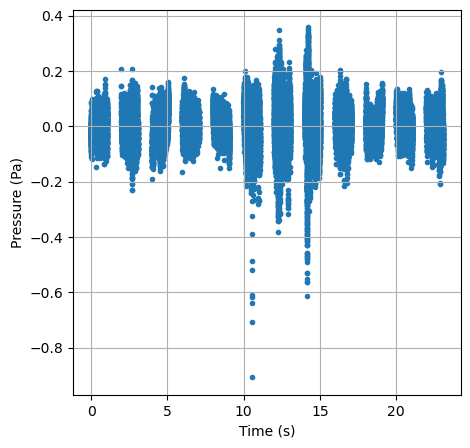

In [77]:
mt = PressureTimeseries(time, pressure)

window_size = 500./3600 # window size is 500 seconds
mt.detrend_timeseries_boxcar(window_size)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.scatter(mt.time, mt.detrended_data, marker='.')
ax.grid(True)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

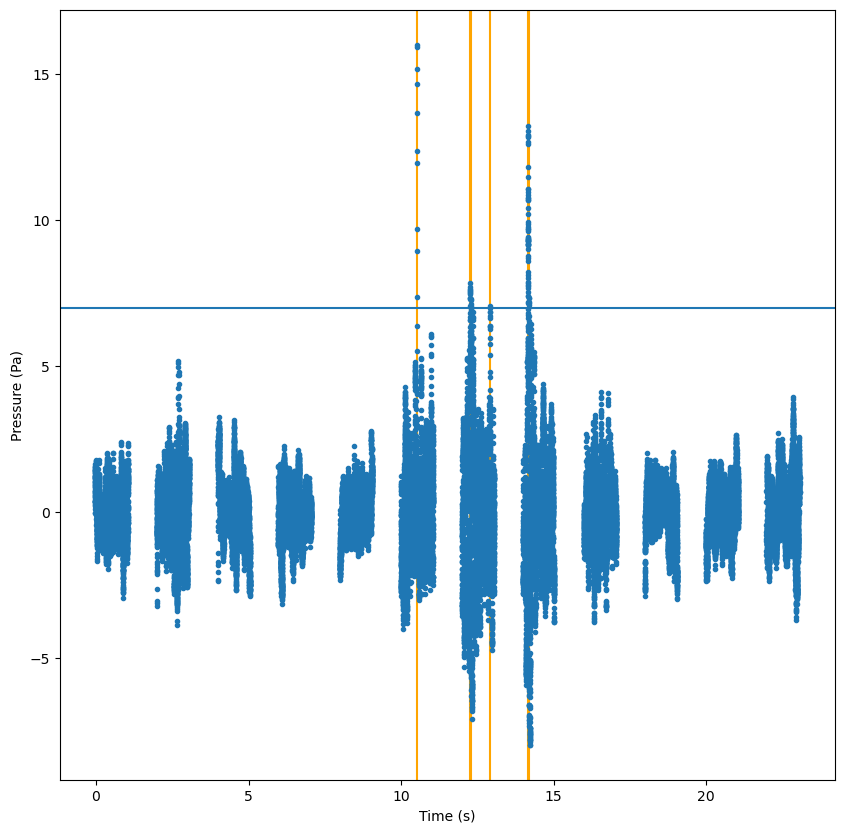

In [78]:
matched_filter_width = 2.*mt.sampling
matched_filter_depth = 1./np.pi
distance_between_peaks = 35
detection_threshold = 7

conv = mt.apply_lorentzian_matched_filter(matched_filter_width, matched_filter_depth)
vortices = mt.find_vortices(detection_threshold=detection_threshold, distance=distance_between_peaks)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.plot(mt.time, mt.convolution, ls='', marker='.')
ax.axhline(detection_threshold)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")

for i in range(len(mt.peak_indices)):
    ax.axvline(mt.time[mt.peak_indices[i]], color="orange", zorder=-1)

fit_all_vortices: vortex 0 couldn't be fit!


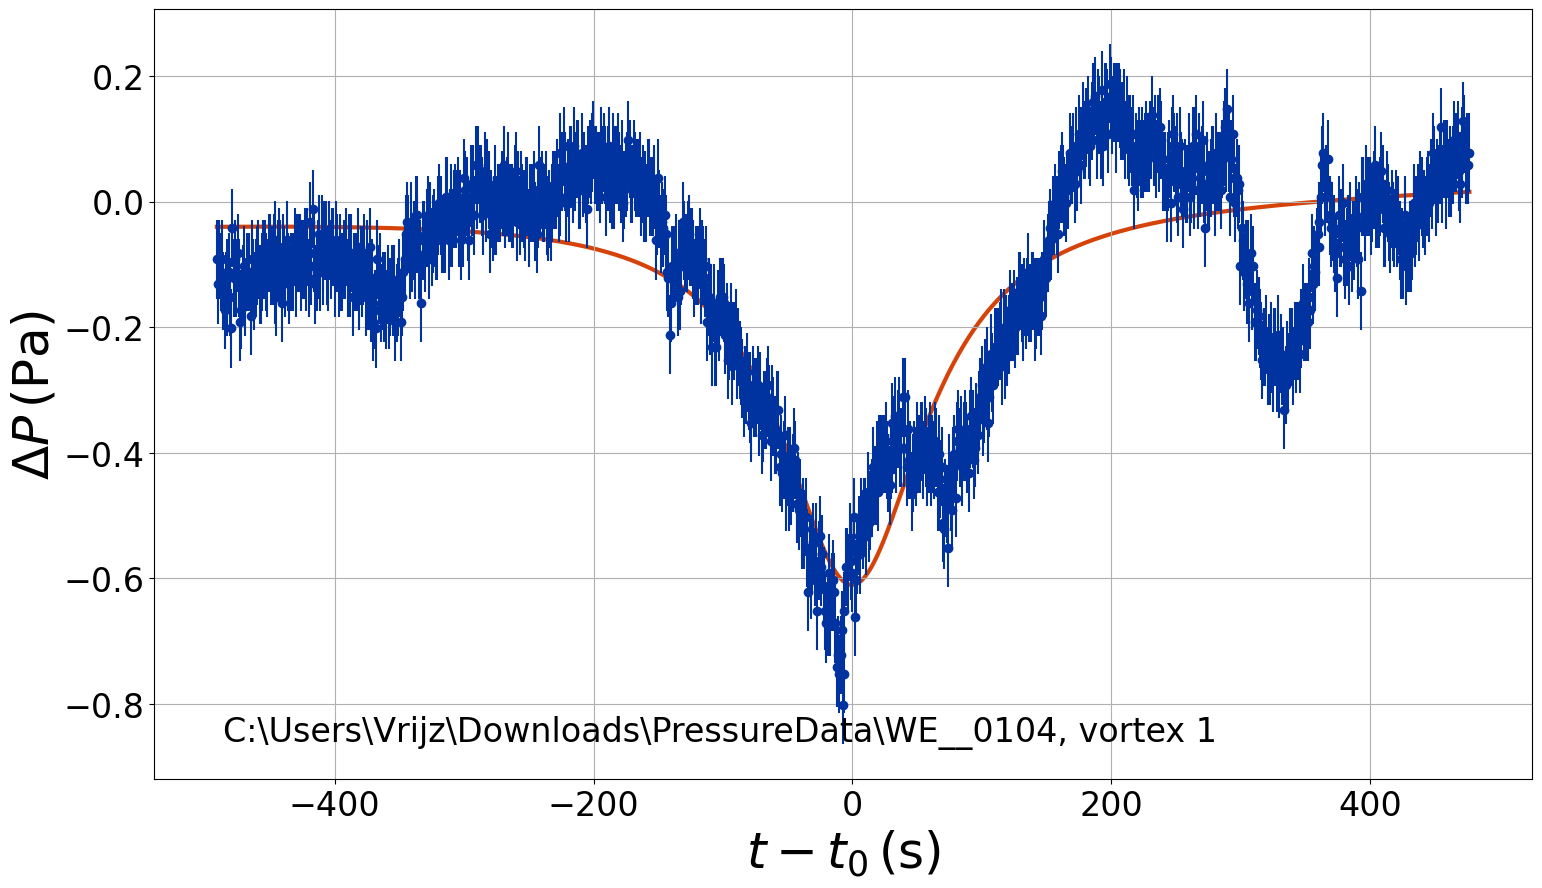

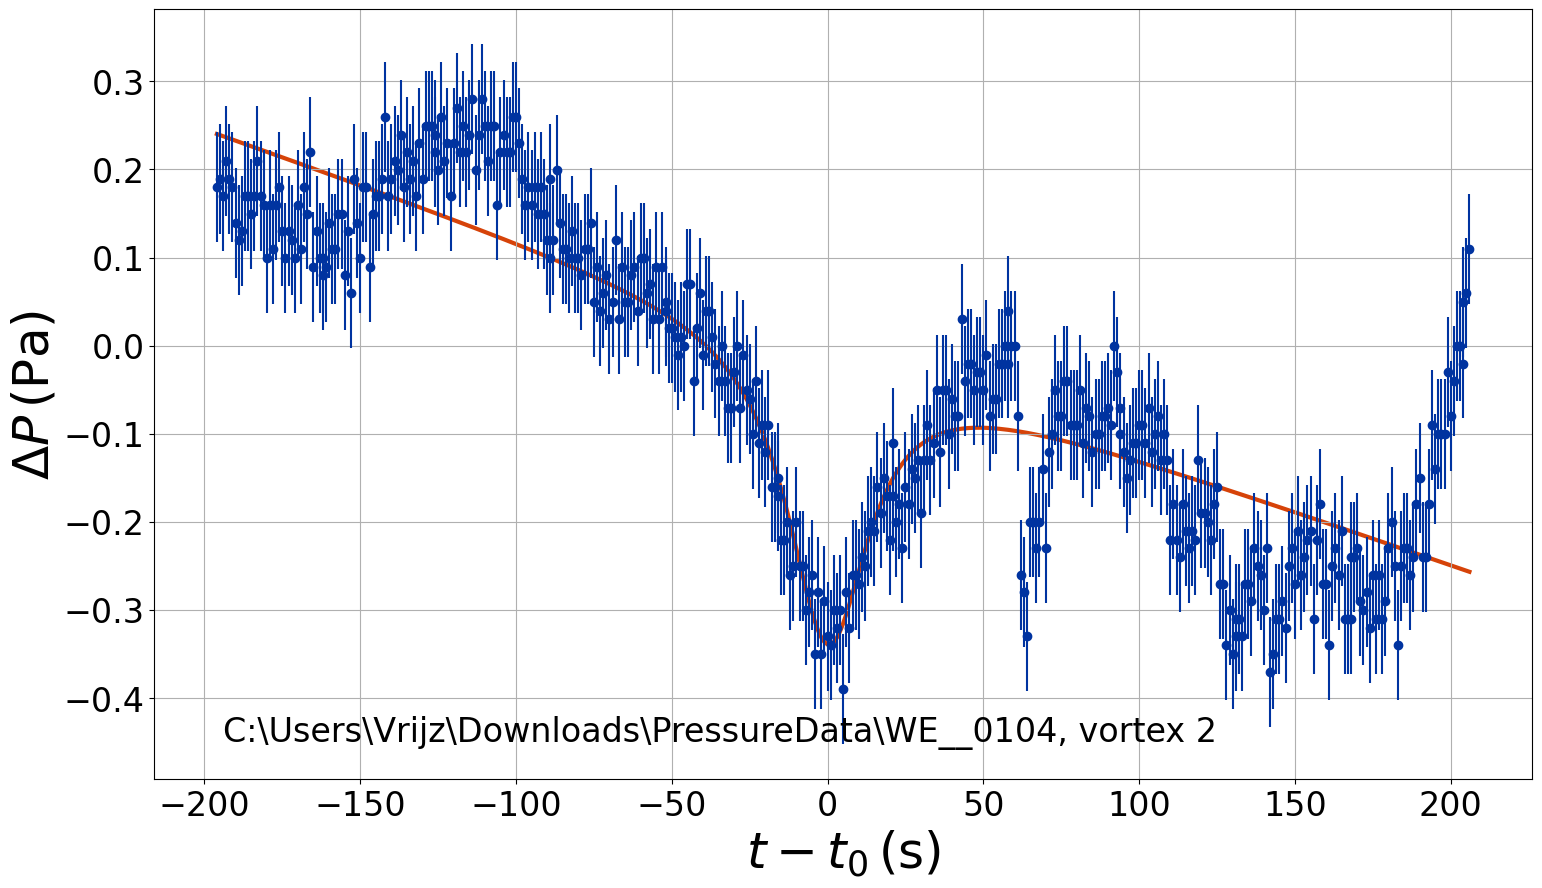

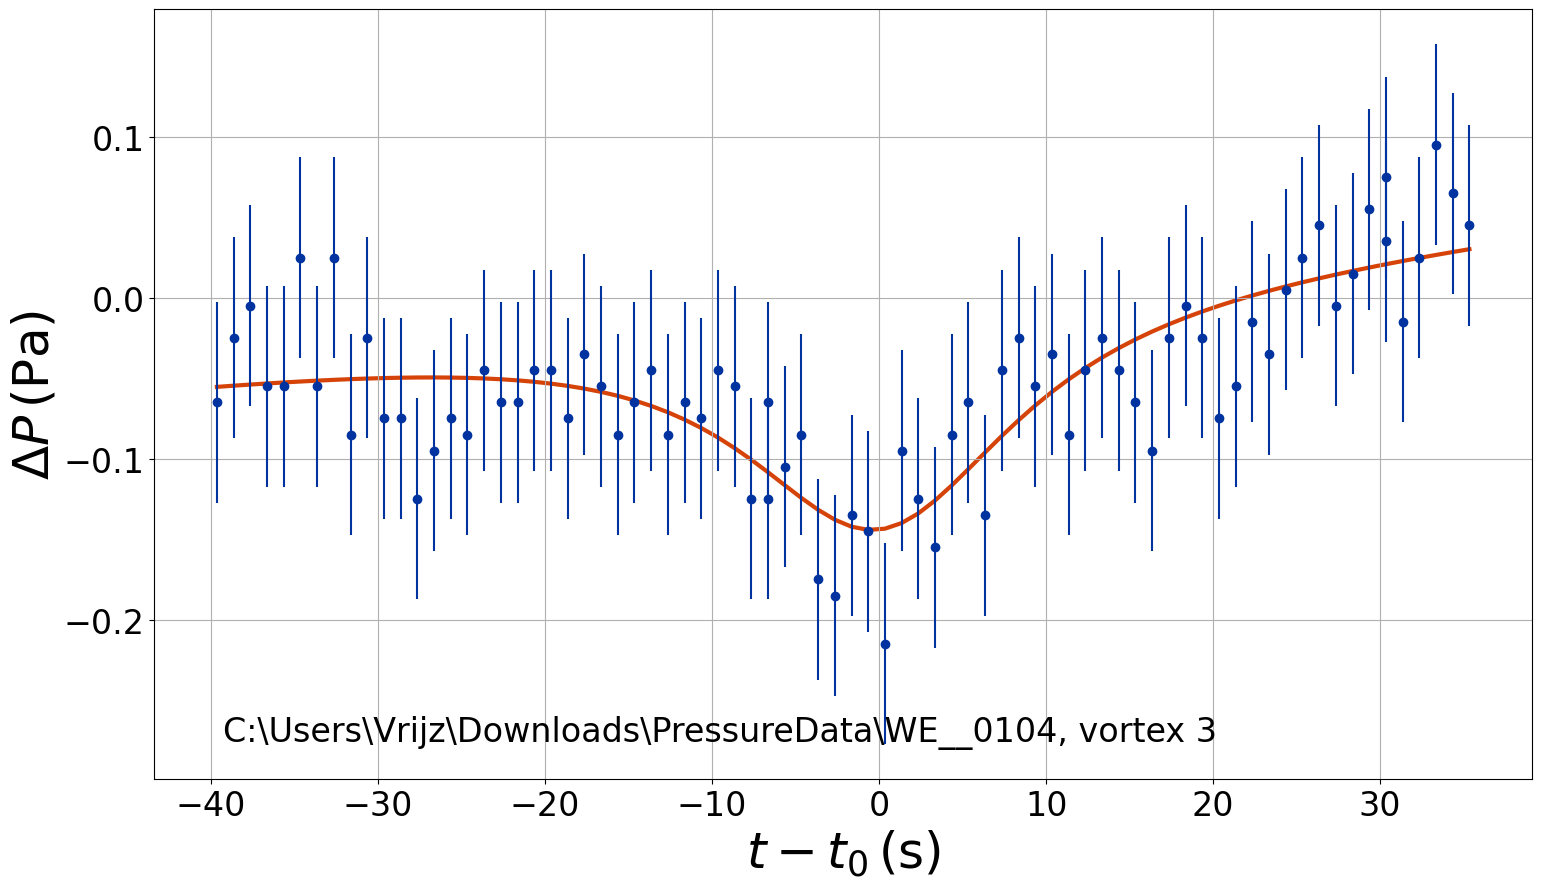

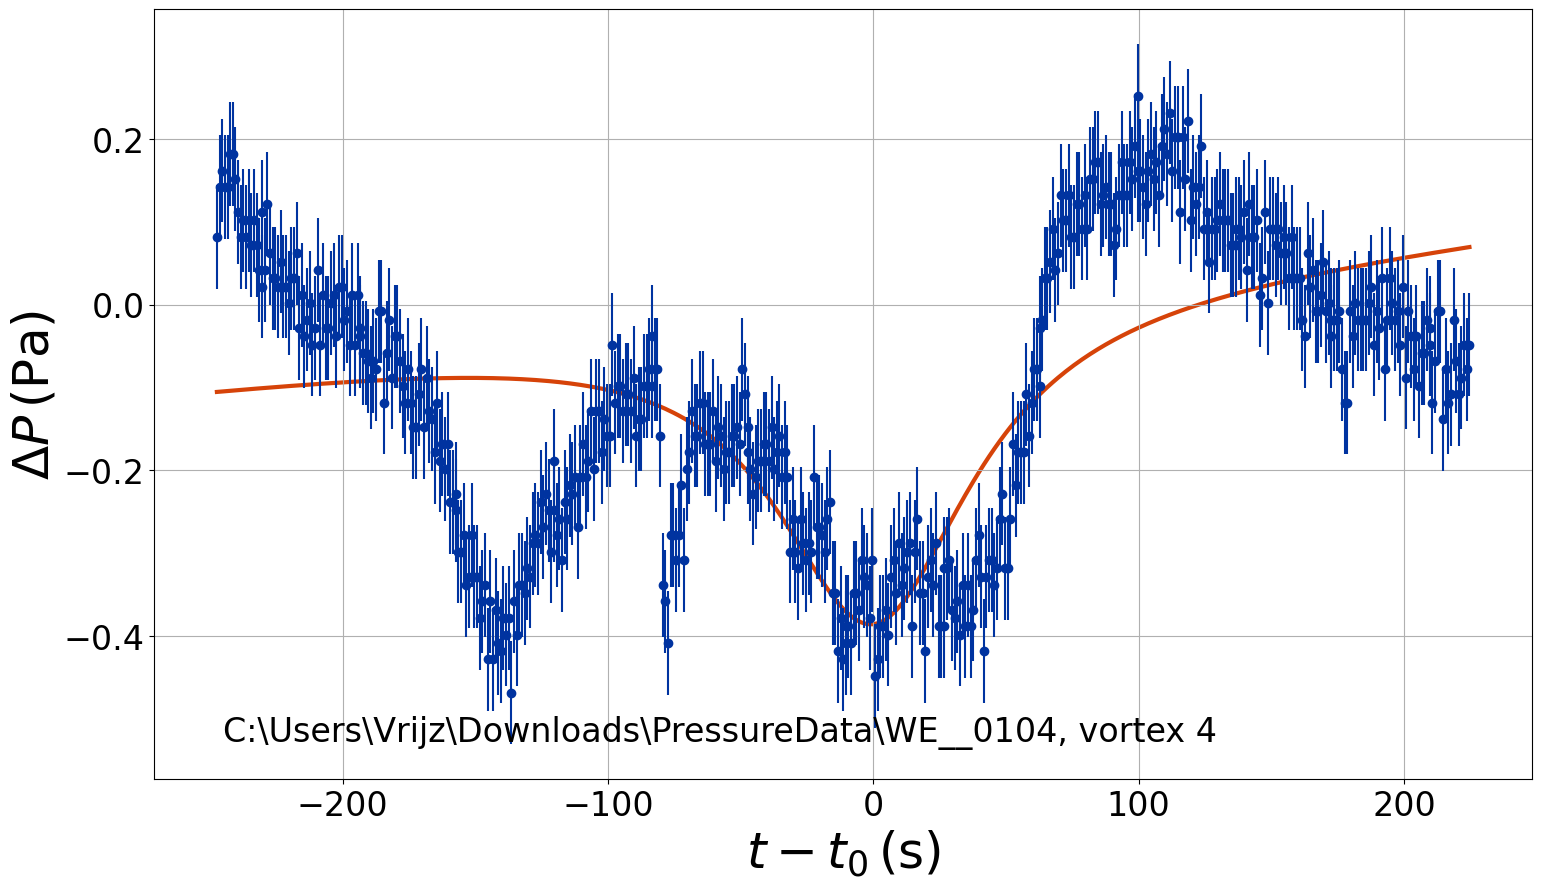

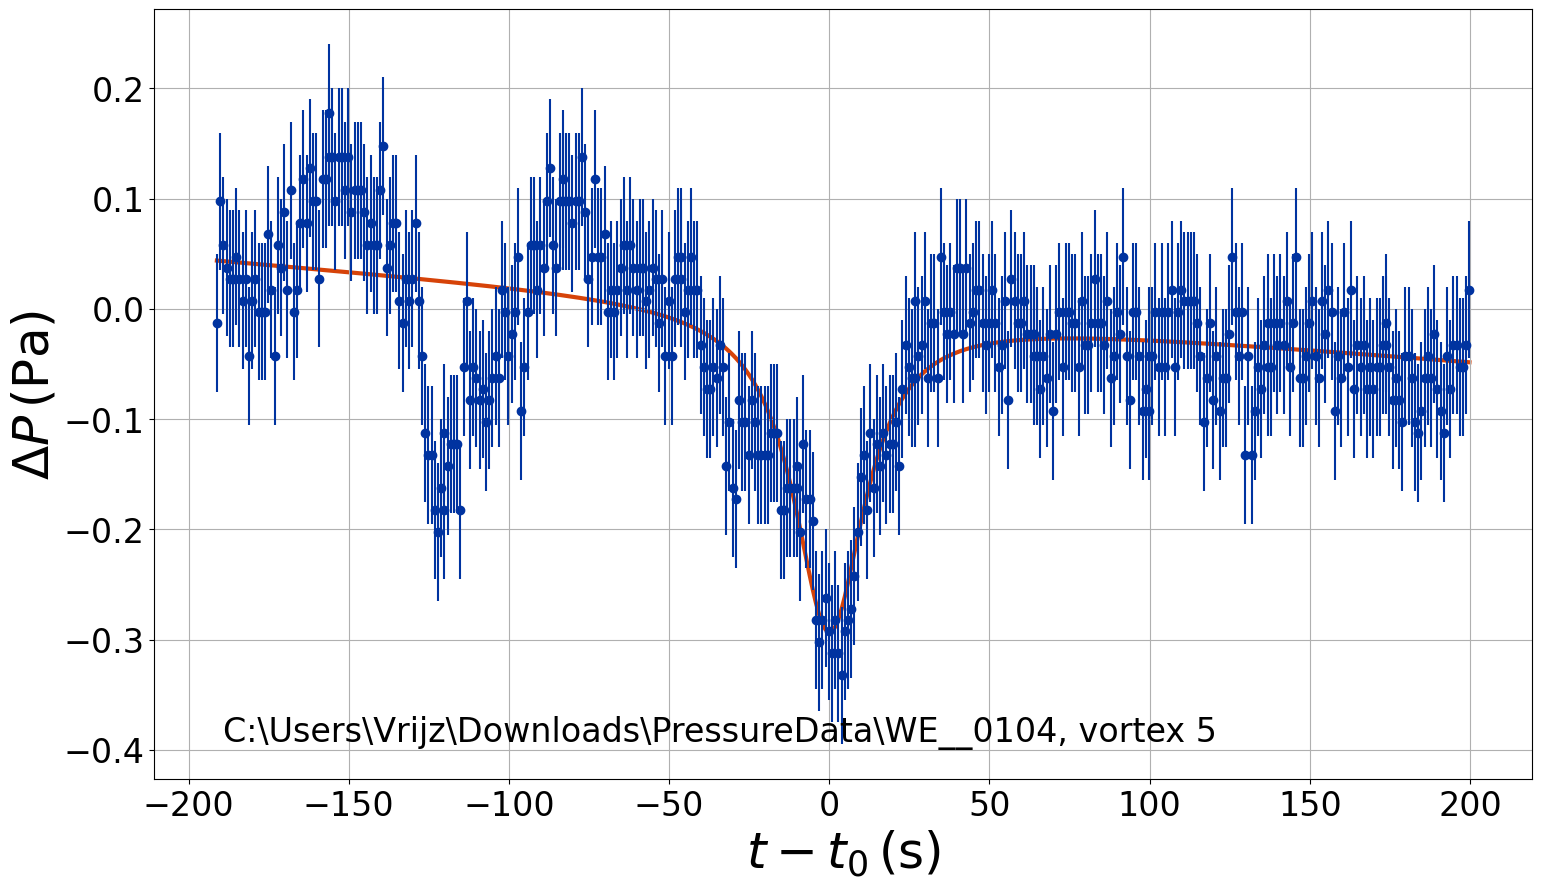

In [79]:
import shutil
import os

#Reduce spam of .csv files from muldoon API but keep it running and making the graphs
#It still needs a file path to load the graphs
dataFolder = r"C:\Users\Vrijz\Downloads\PressureData"

#To save the graphs locally for easy word use
graphsFolder = r"C:\Users\Vrijz\Downloads\PressureGraphs"

## Change sol number here too
mt.fit_all_vortices(filepath=os.path.join(dataFolder, "WE__0104"))


for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(
        os.path.join(graphsFolder, f"vortex_fit_{i-1}.png"),
        dpi=300,
        bbox_inches='tight'
    )

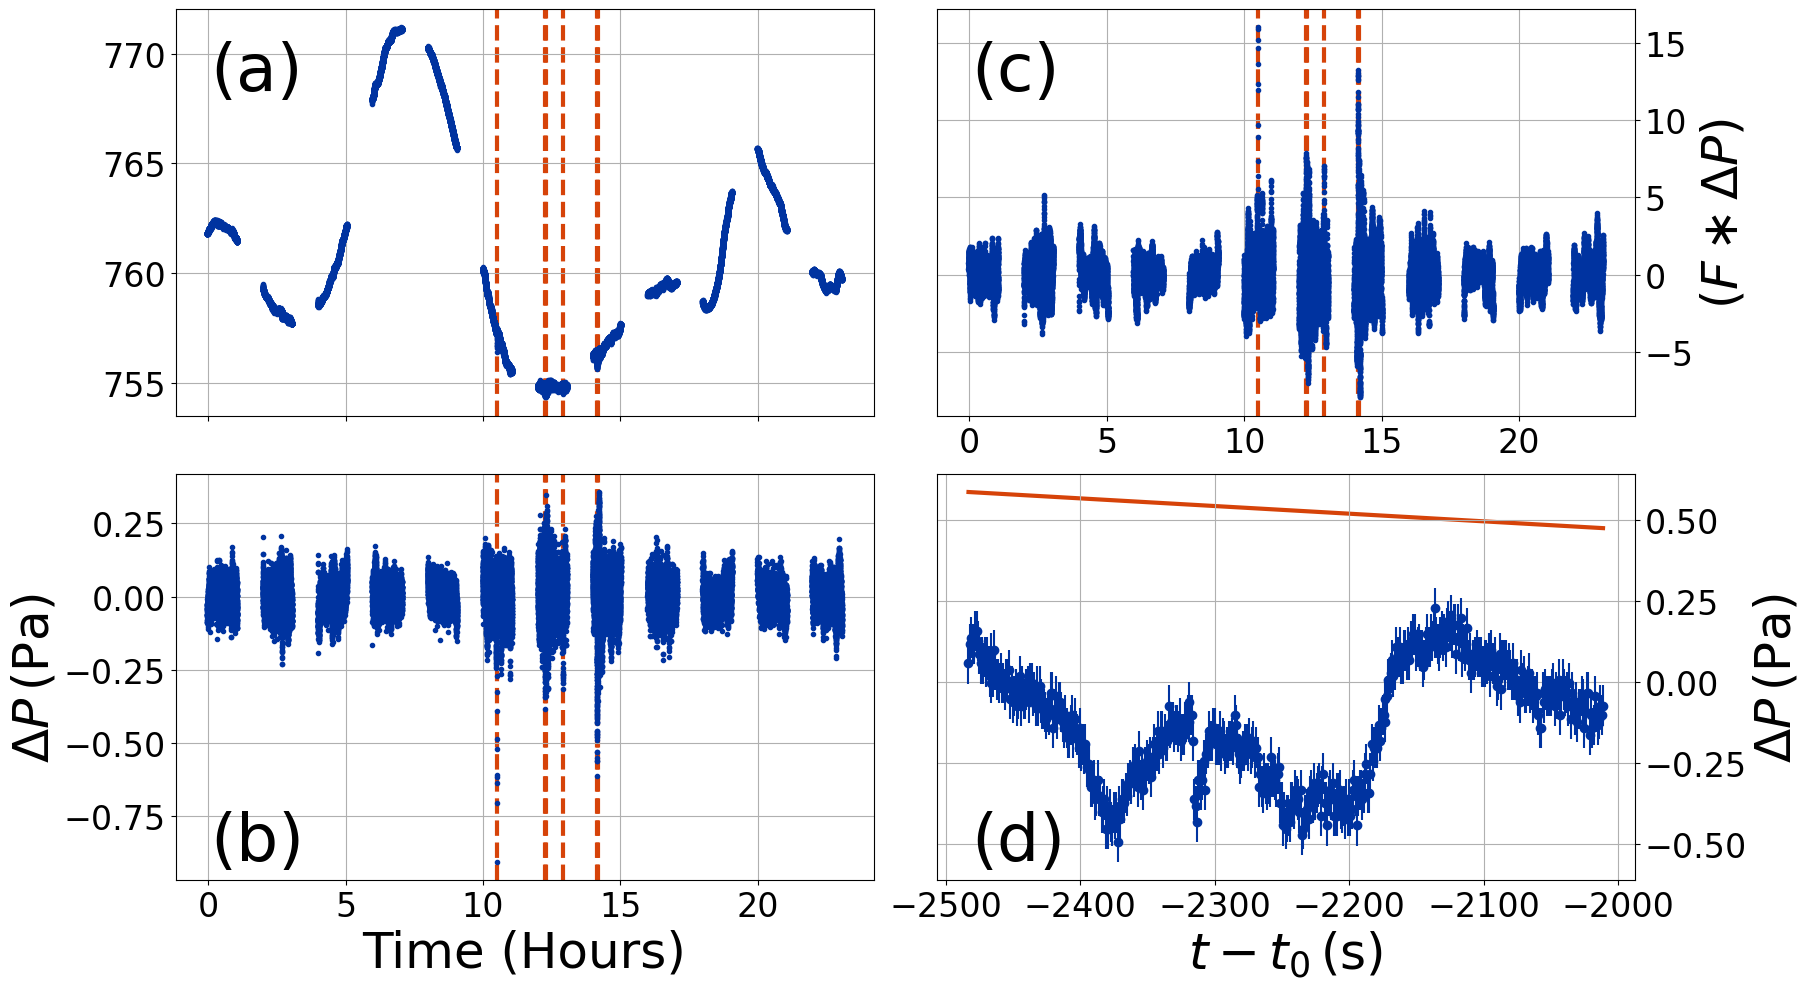

In [81]:
import os
import shutil

# Make final conditioned data figure
finalFourGraphsFolder = r"C:\Users\Vrijz\Downloads\FinalFourGraphs"

#Clear and recreate 
shutil.rmtree(finalFourGraphsFolder)
os.makedirs(finalFourGraphsFolder, exist_ok=True)

 
mt.make_conditioned_data_figure(which_vortex=4);
plt.tight_layout()

for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(
        os.path.join(finalFourGraphsFolder, f"vortex_fit_{i}.png"),
        dpi=300,
        bbox_inches='tight'
    )